# CAFE — end-to-end evaluation on a real RAG system

This notebook does two things at once, on **one real study**:

1. **Showcase** — run CAFE over a genuine compound system (a RAG pipeline on HotpotQA) with real
   factors (retrieval sophistication, model size) and read off which factor drives quality, the
   interactions, and the cost/quality trade-off.
2. **Evaluate CAFE itself** — prove that when CAFE says *"factor X matters / this gap is real / the
   judge is trustworthy,"* it is **correct**. A showcase shows the tool *runs*; an evaluation shows its
   conclusions can be *trusted*. The difference is **ground truth**, which we build into the design.

## The study
A `retrieve → [rerank] → generate` pipeline over **HotpotQA** (hard, multi-hop questions), retrieving
from a shared embedding knowledge base pooled from all the questions' paragraphs. Three factors
(**18 configs**):

| factor | levels | role |
|---|---|---|
| `retrieval` | none · dense · dense_rerank | **anchor + finding** — `none` is *known-worst* (CAFE must find it); dense-vs-rerank is the open question "is reranking worth it?" |
| `model` | qwen3.5 4b · 27b · 122b | the **finding** — does size matter, and how much? (expected ordering = bonus anchor) |
| `placebo` | on · off | **negative control** — a no-op factor whose true effect is zero; CAFE must call it non-significant |

Retrieval uses a **bge-m3 embedder (OpenRouter)**; reranking is an **LLM reranker** (RankGPT-style).
Judged by a strong, **separate** model (deepseek-v4-pro, so it can't self-prefer the qwen systems) on
an ordinal correctness rubric. `temp=0.3`, `reps=1`. (A 4th retrieval level, query `decomposed`, is
deferred until the smoke test shows whether plain `dense` misses second-hop docs.)

## The four evaluation checks
- **E1 — Recovery:** CAFE flags `retrieval` (and the model-size ordering) as real, and `placebo` as null.
- **E2 — Null calibration:** under label permutation, CAFE's false-positive rate ≈ 5%.
- **E3 — Judge ↔ human agreement:** the LLM judge tracks human ratings (Krippendorff's α).
- **E4 — Holdout:** the winning config — *when its gap is significant* — survives a fresh question split.

Flip **`SMOKE = False`** in the next cell to go from a quick plumbing test to the full run.

## 0. Setup & configuration

Everything the notebook needs — all imports and **every knob** — lives in the single cell below. The
one switch that matters day-to-day is **`SMOKE`**: `True` runs a tiny plumbing test (`N=3`) to confirm
the pipeline works end-to-end; `False` runs the real study (`N=50`). The rest fixes the models
(systems, judge, LLM reranker, embedder), the retrieval sizes, and the HotpotQA filters. Nothing later
in the notebook hard-codes these — change them here only.

In [22]:
# ── Imports (everything the notebook needs, in one place) ─────────────────────
import os
import re
import json
import random
import hashlib
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import litellm                          # embeddings (OpenRouter) + underlying LLM calls
from datasets import load_dataset       # HotpotQA (needs the `datasets` extra)

import cafe
from cafe._env import load_env

load_env()   # loads OLLAMA_API_KEY (chat) and OPENROUTER_API_KEY (embeddings) from .env
litellm.suppress_debug_info = True   # silence LiteLLM's "Provider List" cost-map noise on direct embedding calls

# ── Config — flip SMOKE to switch a quick plumbing test vs the full evaluation ─
SMOKE = False                    # True: tiny run to test the pipeline; False: the real study
N = 7 if SMOKE else 50           # number of HotpotQA questions
REPS = 1                         # replications per (config, question)
TEMP = 0.3                       # generation temperature (fixed; not a factor)
SEED = 0                         # reproducibility
DATA_DIR = "data"                # cache for the sampled questions + KB embeddings (don't re-pay)

# Chat models on Ollama Cloud. The `model` factor mixes size AND family (not a pure size ladder),
# so we call it "which model" — the expected quality order still gives a soft recovery anchor. The
# judge is a DIFFERENT family than all three systems, so it can't self-prefer their outputs.
SYSTEM_MODELS = {                # the `generate.model` factor's levels
    "gemma3-4b":    "ollama_cloud/gemma3:4b",
    "gpt-oss-20b":  "ollama_cloud/gpt-oss:20b",
    "gpt-oss-120b": "ollama_cloud/gpt-oss:120b",
}
JUDGE_MODEL = "ollama_cloud/deepseek-v4-pro"
RERANK_MODEL = "ollama_cloud/gpt-oss:20b"   # LLM reranker (RankGPT-style) for the dense_rerank level

# Ollama Cloud reports $0/token (flat subscription), so give CAFE ILLUSTRATIVE per-1k-token prices —
# proportional to model size — so the cost/quality Pareto has a real signal. (Latency is measured for
# free as the honest alternative; these prices are for the demonstration.)
MODEL_PRICE_PER_1K = {"gemma3-4b": 0.00005, "gpt-oss-20b": 0.0002, "gpt-oss-120b": 0.0006}
for _key, _price in MODEL_PRICE_PER_1K.items():
    cafe.set_model_cost(SYSTEM_MODELS[_key], per_1k_tokens=_price)

# Retrieval — embedder via OpenRouter (proper SOTA model, no local install).
EMBED_MODEL = "openrouter/baai/bge-m3"   # verify the exact slug on the first embedding call
TOP_K = 2                                 # paragraphs FED to the generator (both dense & dense_rerank);
                                          # small on purpose → widens the dense-vs-rerank contrast
RETRIEVE_K = 12                           # candidates the embedder pulls before the reranker picks TOP_K
EMBED_COST_USD = 1e-5                      # nominal per-query embedding cost (charged to the retrieve stage)

# HotpotQA question filters (distractor config, validation split)
HOTPOT_LEVEL = "hard"             # hardest questions (most retrieval-dependent) — verify spread at smoke
EXCLUDE_YES_NO = True             # drop yes/no answers (gameable; weaken the RAG anchor)
MIN_ANSWER_WORDS = 10             # drop 1-word answers (richer answers → partial credit is meaningful)
BRIDGE_ONLY = False               # True = only multi-hop "bridge" questions (cleanest anchor)

random.seed(SEED)
np.random.seed(SEED)

# Cache key — anything that changes which questions we sample invalidates the cache.
SAMPLE_KEY = hashlib.md5(json.dumps({
    "N": N, "seed": SEED, "level": HOTPOT_LEVEL, "yes_no": EXCLUDE_YES_NO,
    "min_words": MIN_ANSWER_WORDS, "bridge": BRIDGE_ONLY,
}, sort_keys=True).encode()).hexdigest()[:8]
os.makedirs(DATA_DIR, exist_ok=True)

print(f"SMOKE={SMOKE}  ·  N={N}  ·  reps={REPS}  ·  temp={TEMP}  ·  cache key={SAMPLE_KEY}")
print("systems:", list(SYSTEM_MODELS), " | judge:", JUDGE_MODEL.split("/")[-1],
      " | embedder:", EMBED_MODEL.split("/")[-1])

SMOKE=False  ·  N=50  ·  reps=1  ·  temp=0.3  ·  cache key=214644a9
systems: ['gemma3-4b', 'gpt-oss-20b', 'gpt-oss-120b']  | judge: deepseek-v4-pro  | embedder: bge-m3


## 1. Load, filter & inspect the dataset

We use HotpotQA's **`distractor`** config, **validation** split. Each row ships its own 10 paragraphs
(`context`) + a gold-sentence key (`supporting_facts`) + a short `answer` — the three levels of ground
truth we'll build on. We filter to **hard** questions with **non-yes/no** answers (yes/no is gameable
and would weaken the retrieval anchor), then eyeball a few to confirm they're genuinely multi-hop with
clear short answers — i.e. that the design *makes sense* before we spend anything.

In [23]:
QUESTIONS_PATH = os.path.join(DATA_DIR, f"questions_{SAMPLE_KEY}.json")

if os.path.exists(QUESTIONS_PATH):
    questions = json.load(open(QUESTIONS_PATH))
    print(f"loaded {len(questions)} cached questions  ←  {QUESTIONS_PATH}")
else:
    def keep(ex):
        if ex["level"] != HOTPOT_LEVEL:
            return False
        if EXCLUDE_YES_NO and ex["answer"].strip().lower() in {"yes", "no"}:
            return False
        if len(ex["answer"].split()) < MIN_ANSWER_WORDS:
            return False
        if BRIDGE_ONLY and ex["type"] != "bridge":
            return False
        return True

    raw = load_dataset("hotpotqa/hotpot_qa", "distractor", split="validation")
    pool = raw.filter(keep)
    sampled = pool.shuffle(seed=SEED).select(range(min(N, len(pool))))
    questions = [dict(ex) for ex in sampled]          # plain dicts → JSON-serializable
    json.dump(questions, open(QUESTIONS_PATH, "w"))
    print(f"raw {len(raw)} · after filters {len(pool)} · sampled {len(questions)}  →  saved {QUESTIONS_PATH}")

# Stats on the sampled set (works whether loaded from cache or freshly sampled).
print("type mix:", pd.Series([q["type"] for q in questions]).value_counts().to_dict())
print("answer word-count:",
      pd.Series([len(q["answer"].split()) for q in questions]).describe()[["min", "50%", "max"]].to_dict())

loaded 50 cached questions  ←  data/questions_214644a9.json
type mix: {'bridge': 40, 'comparison': 10}
answer word-count: {'min': 10.0, '50%': 11.0, 'max': 29.0}


In [24]:
# Show BOTH raw fields in full for each sampled question, so their structure is clear:
#   context          = the retrieval POOL (10 paragraphs: 2 gold + 8 distractors)
#   supporting_facts = the RELEVANCE KEY: which sentences (title + index) are actually needed
#                      — these indices point INTO context's sentence lists.
for ex in questions:
    gold_titles = set(ex["supporting_facts"]["title"])
    print("=" * 100)
    print("QUESTION:", ex["question"])
    print("ANSWER:  ", ex["answer"], f"   ({ex['type']}, {ex['level']})")

    print("\nsupporting_facts  (which sentences are needed):")
    for t, sid in zip(ex["supporting_facts"]["title"], ex["supporting_facts"]["sent_id"]):
        print(f"    {t!r}  →  sentence #{sid}")

    print(f"\ncontext  ({len(ex['context']['title'])} paragraphs; ★ = gold, the rest are distractors):")
    for title, sents in zip(ex["context"]["title"], ex["context"]["sentences"]):
        mark = "★" if title in gold_titles else " "
        print(f"  {mark} [{title}]")
        for i, s in enumerate(sents):
            print(f"        {i}: {s.strip()}")
    print()

QUESTION: The first book in the Sprawl Trilogy won what three awards?
ANSWER:   Nebula Award, the Philip K. Dick Award, and the Hugo Award    (bridge, hard)

supporting_facts  (which sentences are needed):
    'Sprawl trilogy'  →  sentence #0
    'Neuromancer'  →  sentence #1

context  (10 paragraphs; ★ = gold, the rest are distractors):
    [Governors Awards]
        0: The Governors Awards presentation is an annual award ceremony hosted by the Academy of Motion Picture Arts and Sciences (AMPAS), at the Grand Ballroom of the Hollywood and Highland Center, in the Hollywood district of Los Angeles, California.
        1: Three awards that signify lifetime achievement within the film industry – the Academy Honorary Award, the Jean Hersholt Humanitarian Award, and the Irving G. Thalberg Memorial Award – are presented at this ceremony.
        2: The first Governors Awards ceremony was held on November 14, 2009.
        3: Prior to this, these three awards were formally presented during th

## 2. Build the pooled knowledge base + bge-m3 retriever

We pool **every sampled question's 10 `context` paragraphs into one shared KB** (dedup by title), so a
given question's 2 gold paragraphs hide among *all the other questions'* paragraphs — a realistic
retrieval problem (not the trivial 2-of-10). We embed the KB with **bge-m3 (OpenRouter)** and retrieve
by cosine similarity.

Then the crucial sanity check: **recall@k against `supporting_facts`** — does the retriever actually
pull each question's *gold* paragraphs into the top-k? If recall is high, the `dense` level is real; if
it's low, dense retrieval is missing the evidence (which is exactly the gap the `dense_rerank` and
possible `decomposed` levels are meant to close — an interesting finding either way).

In [25]:
# Pool the contexts into one KB (dedup by article title). Each paragraph = "Title. sentences…".
def paragraph_text(title, sentences):
    return f"{title}. " + " ".join(s.strip() for s in sentences)

kb = {}  # title -> text
for ex in questions:
    for title, sents in zip(ex["context"]["title"], ex["context"]["sentences"]):
        kb.setdefault(title, paragraph_text(title, sents))

KB_TITLES = list(kb)
KB_DOCS = [kb[t] for t in KB_TITLES]
print(f"KB: {len(KB_DOCS)} unique paragraphs pooled from {len(questions)} questions "
      f"(≈{len(KB_DOCS)/max(1,len(questions)):.1f} per question after dedup)")

KB: 500 unique paragraphs pooled from 50 questions (≈10.0 per question after dedup)


In [26]:
# Embed with bge-m3 (OpenRouter), normalized for cosine similarity.
def embed(texts, batch=64):
    vecs = []
    for i in range(0, len(texts), batch):
        resp = litellm.embedding(model=EMBED_MODEL, input=texts[i:i + batch])
        vecs.extend(d["embedding"] for d in resp["data"])
    arr = np.asarray(vecs, dtype=np.float32)
    return arr / (np.linalg.norm(arr, axis=1, keepdims=True) + 1e-9)

# The KB embeddings are the expensive bit — cache them (keyed on the sample + embedder).
KB_EMB_PATH = os.path.join(DATA_DIR, f"kb_emb_{SAMPLE_KEY}_{EMBED_MODEL.split('/')[-1]}.npy")
if os.path.exists(KB_EMB_PATH):
    KB_EMB = np.load(KB_EMB_PATH)
    assert len(KB_EMB) == len(KB_DOCS), "cache/KB size mismatch — delete DATA_DIR and rerun"
    print(f"loaded cached KB embeddings  ←  {KB_EMB_PATH}   {KB_EMB.shape}")
else:
    KB_EMB = embed(KB_DOCS)
    np.save(KB_EMB_PATH, KB_EMB)
    print(f"embedded + saved KB  →  {KB_EMB_PATH}   {KB_EMB.shape}")   # (n_docs, 1024) for bge-m3

def retrieve(query, k):
    """Top-k (title, text, score) from the KB by cosine similarity (query embedded live)."""
    q = embed([query])[0]
    sims = KB_EMB @ q
    idx = np.argsort(-sims)[:k]
    return [(KB_TITLES[i], KB_DOCS[i], float(sims[i])) for i in idx]

loaded cached KB embeddings  ←  data/kb_emb_214644a9_bge-m3.npy   (500, 1024)


In [27]:
# Sanity check — does the retriever pull each question's GOLD paragraphs into the top-k?
# recall@TOP_K = what `dense` actually FEEDS the generator; recall@RETRIEVE_K = the candidate
# pool the reranker gets to reorder; recall@2 = what a tighter top-2 would feed (more rerank room).
def gold_recall(ex, k):
    got = {t for t, _, _ in retrieve(ex["question"], k)}
    gold = set(ex["supporting_facts"]["title"])
    return len(got & gold) / len(gold)

for k in sorted({2, TOP_K, RETRIEVE_K}):
    recalls = [gold_recall(ex, k) for ex in questions]
    if k == TOP_K:
        role = "fed to generator by `dense`"
    elif k == RETRIEVE_K:
        role = "candidate pool for the reranker"
    else:
        role = "if only top-2 were fed (more room for rerank)"
    print(f"gold recall@{k:<2}: mean {np.mean(recalls):.2f}   ({role})")

# Peek at one question (★ = gold); the cutoff line shows what `dense` feeds vs what rerank sees.
ex = questions[0]
gold = set(ex["supporting_facts"]["title"])
print(f"\nQ: {ex['question']}\n   gold: {sorted(gold)}\n   top-{RETRIEVE_K} retrieved (★ = gold):")
for rank, (t, _, score) in enumerate(retrieve(ex["question"], RETRIEVE_K), 1):
    cut = f"   ←—— top-{TOP_K} cutoff (what `dense` feeds the LLM)" if rank == TOP_K else ""
    print(f"     {'★' if t in gold else ' '} {score:.3f}  {t}{cut}")

gold recall@2 : mean 0.76   (fed to generator by `dense`)
gold recall@12: mean 0.97   (candidate pool for the reranker)

Q: The first book in the Sprawl Trilogy won what three awards?
   gold: ['Neuromancer', 'Sprawl trilogy']
   top-12 retrieved (★ = gold):
     ★ 0.631  Sprawl trilogy
       0.504  Bridge trilogy   ←—— top-2 cutoff (what `dense` feeds the LLM)
     ★ 0.500  Neuromancer
       0.469  Tessier-Ashpool
       0.448  Mona Lisa Overdrive
       0.441  Molly Millions
       0.440  The Story of the Weasel
       0.431  Burning Chrome (short story collection)
       0.426  The Fortress Series
       0.422  Count Zero
       0.402  Johnny Mnemonic
       0.371  C. J. Cherryh


## From screening to the study — what the pilot established

Everything above is a **calibration pilot**: before committing tokens to the full factorial, we
verified the experimental substrate is sound and used it to *lock the retrieval parameters
empirically* rather than by guesswork — the grounding a reviewer should expect before believing any
downstream result.

**What we established**

- **A valid task with built-in ground truth.** HotpotQA (hard · multi-hop · non-yes/no · ≥10-word
  answers) yields genuinely two-hop factual questions, each shipping its own paragraphs *and* a
  gold-relevance key — giving us three levels of ground truth (corpus, relevant docs, gold answer).
  50 questions sampled from the 77 that pass the filters.
- **A realistic retrieval problem.** Pooling every question's paragraphs into one **500-document** KB
  (bge-m3 embeddings) forces each question's 2 gold paragraphs to be found among ~500 distractors —
  not the trivial 2-of-10 of the raw dataset.
- **A recall analysis that fixes the knobs.** Gold-paragraph recall on the pooled KB was
  **0.76 @2 · 0.87 @4 · 0.97 @12**, and three design decisions follow *directly* from it:
  - **Feed the generator `TOP_K = 2`** (for both retrieval levels): the 0.76→0.97 gap between raw
    top-2 and the full candidate pool is the **widest room for reranking to demonstrably help**, so
    it maximises the contrast between `dense` and `dense_rerank` — the study's open question.
  - **Give the reranker `RETRIEVE_K = 12` candidates** (recall 0.97): the gold evidence is almost
    always *in* the pool it reorders, so any failure is the reranker's, not the retriever's.

**The design this locks in** — one **18-configuration** factorial:
`retrieval {none, dense, dense_rerank} × model {qwen3.5 4b, 27b, 122b} × placebo {on, off}`, judged on
an ordinal correctness rubric by a separate strong model (deepseek-v4-pro), at `temp=0.3`, `reps=1`.
`retrieval` is the known-signed **anchor** (none must lose), `model` is the open **finding**, `placebo`
is the **negative control** that must come out null.

**How we proceed**

- **§3** builds the compound RAG system — the three retrieval levels, the LLM reranker, and generation.
- **§4** wires it into a CAFE `Study` and runs the factorial.
- **§5** runs the four checks that test whether CAFE's conclusions are *correct*, not merely plausible:
  **E1** recovery (does CAFE flag `retrieval` and the size ordering, and null the `placebo`?), **E2**
  false-positive calibration (label permutation), **E3** judge↔human agreement (Krippendorff's α), and
  **E4** within-distribution holdout.

## 3. The compound RAG system (Mode B — instrumented)

We build the system as a CAFE **`Pipeline`** — techniques registered on a pipeline object we
own (no global state) — rather than an opaque function, so CAFE sees *inside* the pipeline: it
records per-stage time, tokens and cost, captures a trace of every run, and can auto-detect the
stage order. Each pipeline stage is a factor:

- **`retrieve`** — three registered techniques (`none` · `dense` · `dense_rerank`); the reranker is an
  LLM (RankGPT-style) that reorders the top-`RETRIEVE_K` candidates down to `TOP_K`.
- **`generate`** — one technique; the **model** is a tunable knob (`generate.model` factor → the
  qwen3.5 size ladder). Since `generate` has a single technique it's a *fixed* stage — it needs no
  factor of its own; CAFE just runs it.
- **`finalize`** — the **placebo**: two techniques (`on`/`off`) that both return the answer *unchanged*.
  A negative control whose true effect is exactly zero — CAFE must call it non-significant.

The pipeline is `retrieve → generate → finalize`, run through an instrumented `ctx`; the pipeline
object itself becomes the study's `system` in §4.

In [28]:
pipe = cafe.Pipeline()   # techniques register onto this pipeline

# ── the LLM reranker (RankGPT-style): the model reorders candidates by relevance ──
async def llm_rerank(query, candidates, k):
    listing = "\n".join(f"[{i}] {text}" for i, (_, text, _) in enumerate(candidates, 1))
    prompt = (f"Question: {query}\n\nPassages:\n{listing}\n\n"
              f"Rank the passages by how well they help answer the question. "
              f"Reply with ONLY the {k} best passage numbers, best first, e.g. '3 1'.")
    raw = await cafe.complete(RERANK_MODEL, [{"role": "user", "content": prompt}], temperature=0.0)
    picks, seen, order = [int(n) for n in re.findall(r"\d+", raw)], set(), []
    for p in picks:                                  # parse, dedup, keep 1-based → 0-based
        if 1 <= p <= len(candidates) and p not in seen:
            seen.add(p); order.append(candidates[p - 1])
    return (order or candidates)[:k]                 # fall back to dense order on a parse failure

# ── retrieve: three techniques → the `retrieve` factor. The fixed embedding cost is DECLARED on
#    the decorator (cost_usd=); the reranker's LLM cost is tracked automatically via cafe.complete. ──
@pipe.technique(stage="retrieve", name="none")
async def retrieve_none(ctx, query):
    return []                                        # no evidence — parametric memory only (the anchor)

@pipe.technique(stage="retrieve", name="dense", cost_usd=EMBED_COST_USD)
async def retrieve_dense(ctx, query):
    return [text for _, text, _ in retrieve(query, TOP_K)]

@pipe.technique(stage="retrieve", name="dense_rerank", cost_usd=EMBED_COST_USD)
async def retrieve_dense_rerank(ctx, query):
    cands = retrieve(query, RETRIEVE_K)              # top-RETRIEVE_K candidates …
    order = await llm_rerank(query, cands, TOP_K)    # … LLM reorders → keep TOP_K
    return [text for _, text, _ in order]

# ── generate: ONE technique; `model` is a tunable knob varied by the `generate.model` factor (§4).
#    `generate` is a FIXED stage (a single technique) → it needs no factor of its own.
#    The prompt forces an attempt even with no context, so `retrieve=none` measures the model's
#    parametric knowledge uniformly (not just whether a small model refuses). ──
@pipe.technique(stage="generate", name="answer")
async def generate_answer(ctx, query, docs, model="gpt-oss-20b"):
    context = "\n\n".join(docs) if docs else "(no documents retrieved)"
    return await cafe.complete(SYSTEM_MODELS[model], [
        {"role": "system", "content": "Answer the question using the provided context when it helps. "
         "If the context is missing or insufficient, still give your best answer from your own "
         "knowledge. Be concise and factual."},
        {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {query}\nAnswer:"},
    ], temperature=TEMP)

# ── finalize: the PLACEBO — both levels return the answer UNCHANGED (a true no-op) ──
@pipe.technique(stage="finalize", name="on")
async def finalize_on(ctx, answer):
    return answer

@pipe.technique(stage="finalize", name="off")
async def finalize_off(ctx, answer):
    return answer

# ── compose the pipeline: retrieve → generate → finalize, through an instrumented ctx ──
@pipe.compose
async def rag_system(config, item, ctx):
    docs = await ctx.run("retrieve", query=item["text"])
    answer = await ctx.run("generate", query=item["text"], docs=docs)
    return await ctx.run("finalize", answer=answer)

print("stages:", pipe.stages())

stages: ['retrieve', 'generate', 'finalize']


## 4. The factorial study & run

We hand the pipeline to a `cafe.Study` with the three factors — `retrieve` (the anchor),
`generate.model` (the model ladder), `finalize` (the placebo) — over the 50 questions, judged by the
separate **deepseek-v4-pro** on **your own** ordinal correctness rubric + prompt (next cell — the judge
sees the gold answer). That's **18 configs × 50 questions × 1 rep = 900** system runs + 900 judge calls.

Before spending a token we sanity-check: `study.check()` (design adequacy), `cafe.pipeline(study)` (the
detected topology + levels), `study.preview_judge_prompt()` (the exact judge input), and
`study.preflight()` (a cost/time estimate from one input per config). Then the real run — **resumable**:
answers and verdicts are checkpointed to `data/`, so a crash or a rate-limit hiccup never loses
progress (just re-run the cell to continue).

### The rubric & judge — yours to edit

You control both the **rubric** (the scale + level descriptions the judge scores on) and the **judge
prompt** (write a `prompt_template`, or lean on a preset). The cell below is a *starter* — edit the
levels, the `instruction`, and the `prompt_template` freely. `scale_type` drives the statistics
(**ordinal → CLMM**). The `.preview(...)` prints the exact judge input (no LLM call) so you can iterate
before spending; the study picks these up as `RUBRIC` and `JUDGE`.

In [29]:
# ── Your rubric & judge — EDIT THESE FREELY. ───────────────────────────────────
# Prompt placeholders: {instruction} {question} {answer} {reference} {scale} {grade} {min} {max}
# Precedence for the judge prompt: JUDGE.prompt_template > RUBRIC.prompt_template > preset.
# The prompt must end by eliciting a "GRADE: <n>" line (CAFE also auto-uses JSON where supported).

RUBRIC = cafe.Rubric(
    name="hotpot_correctness",
    scale_type=cafe.ScaleType.ordinal,               # ordinal → CLMM  (numeric → linear, binary → logistic)
    levels=[
        cafe.Level(0, "incorrect", "The answer is factually incorrect or off-topic."),
        cafe.Level(1, "partial",   "The answer is partially correct."),
        cafe.Level(2, "correct",   "The answer is fully correct; wording does not matter."),
    ],
    instruction=("Grade whether the ANSWER correctly answers the QUESTION, using the REFERENCE as the "
                 "gold answer. Judge factual correctness, not phrasing or length; award partial credit "
                 "for a partially-correct answer."),
    prompt_template=(
        "{instruction}\n\n"
        "[BEGIN DATA]\n"
        "***\n"
        "Question: {question}\n"
        "***\n"
        "Reference (gold) answer: {reference}\n"
        "***\n"
        "Answer to grade: {answer}\n"
        "***\n"
        "[END DATA]\n\n"
        "Reason briefly, then score on this scale:\n{scale}\n\n"
        "End with exactly one final line, and nothing after it:\n"
        "GRADE: <{grade}>"
    ),
)

JUDGE = cafe.LLMJudge(
    model=JUDGE_MODEL,
    system_prompt=("You will be shown a question, a reference (gold) answer, and an answer to grade. "
                   "Follow the grading rules the user gives you, and be a fair, factual grader — judge "
                   "only whether the answer is factually correct against the reference, not its style "
                   "or length."),
)

# Preview the EXACT judge input on a real question (no LLM call) — iterate on the wording here:
print(JUDGE.preview(RUBRIC, question=questions[0]["question"], answer="Arthur's Magazine.",
                    reference=questions[0]["answer"]))

[SYSTEM]
You will be shown a question, a reference (gold) answer, and an answer to grade. Follow the grading rules the user gives you, and be a fair, factual grader — judge only whether the answer is factually correct against the reference, not its style or length.

[USER]
Grade whether the ANSWER correctly answers the QUESTION, using the REFERENCE as the gold answer. Judge factual correctness, not phrasing or length; award partial credit for a partially-correct answer.

[BEGIN DATA]
***
Question: The first book in the Sprawl Trilogy won what three awards?
***
Reference (gold) answer: Nebula Award, the Philip K. Dick Award, and the Hugo Award
***
Answer to grade: Arthur's Magazine.
***
[END DATA]

Reason briefly, then score on this scale:
  0 = incorrect: The answer is factually incorrect or off-topic.
  1 = partial: The answer is partially correct.
  2 = correct: The answer is fully correct; wording does not matter.

End with exactly one final line, and nothing after it:
GRADE: <exact

In [30]:
# Each study item: text = question (fed to the pipeline + judge), reference = gold answer (for the
# reference-guided judge), id = stable key (for resumable checkpointing).
dataset = [{"id": str(q.get("id", i)), "text": q["question"], "reference": q["answer"]}
           for i, q in enumerate(questions)]

study = cafe.Study(
    name="hotpotqa-rag",
    system=pipe,                                            # the Pipeline from §3 IS the system
    factors=[
        pipe.factor("retrieve"),                            # none · dense · dense_rerank  (the anchor)
        cafe.Factor("generate.model", list(SYSTEM_MODELS)), # 4b · 27b · 122b  (the model knob → generate)
        pipe.factor("finalize"),                            # on · off  (the placebo / negative control)
    ],
    dataset=dataset,
    rubric=RUBRIC,                                          # your custom rubric (above)
    judge=JUDGE,                                            # your custom judge (above)
    replications=REPS,
)
study   # the run plan: configs × items × reps

Study('hotpotqa-rag': 18 configs × 50 items × 1 reps = 900 runs; factors: retrieve, generate.model, finalize; judged by ollama_cloud/deepseek-v4-pro)

In [31]:
# Design adequacy (free, runs nothing) + the detected pipeline topology (runs ONE config once).
print("design check:", study.check() or "ok")
print()
print(cafe.pipeline(study).show())   # observed stage order + each stage's levels

design check: ok

pipeline:  retrieve  →  generate  →  finalize

  retrieve       levels: none, dense, dense_rerank
  generate       levels: answer
  finalize       levels: on, off


In [32]:
# Preflight: one input through every configuration (no reps, no judging) → a cost/time estimate for
# the full run, plus the judge-call count and design warnings. Cheap (~18 generations here).
print(study.preflight().show())

preflight — one input through every configuration:
  [finalize=off·generate.model=gemma3-4b·retrieve=dense] The context doesn’t specify which awards “Neuromancer” (the first book in the Sp
  [finalize=off·generate.model=gemma3-4b·retrieve=none] The first book in the Sprawl Trilogy, *Newt in a Nutshell*, won the Arthur C. Cl
  [finalize=on·generate.model=gemma3-4b·retrieve=dense] The context doesn't specify which awards “Neuromancer” (the first book in the Sp
  [finalize=off·generate.model=gpt-oss-120b·retrieve=none] The first book, **Neuromancer**, earned three major science‑fiction honors:    1
  [finalize=on·generate.model=gpt-oss-120b·retrieve=none] The first book, *Neuromancer*, won the Hugo Award, the Nebula Award, and the Phi
  [finalize=off·generate.model=gpt-oss-20b·retrieve=none] The first book of the Sprawl Trilogy, **Neuromancer**, received three major awar
  [finalize=on·generate.model=gemma3-4b·retrieve=none] The first book in the Sprawl Trilogy, *Newt in a Nutshell*, won 

### Run it — resumable

This is the real spend (**~900 generations + rerank calls + ~900 judge calls** at `N=50`). Both phases
are **checkpointed** to `data/`: if it crashes or Ollama Cloud rate-limits, just re-run the cell and it
resumes where it left off (already-done `(config, question)` and `(answer, judge)` pairs are skipped).
Lower `concurrency` if you hit rate limits.

In [33]:
ANSWERS_CKPT = os.path.join(DATA_DIR, f"answers_{SAMPLE_KEY}.jsonl")   # resumable answer phase
VERDICTS_CKPT = os.path.join(DATA_DIR, f"verdicts_{SAMPLE_KEY}.jsonl")  # resumable judging phase

result = study.evaluate(
    checkpoint_path=ANSWERS_CKPT,
    judge_checkpoint_path=VERDICTS_CKPT,
    concurrency=3,
)
result

hotpotqa-rag: answers:   0%|          | 0/900 [00:00<?, ?it/s]

judging:   0%|          | 0/900 [00:00<?, ?it/s]

Evaluation(900 answers · 18 configs · 50 inputs · 900 ratings · best: finalize=on·generate.model=gpt-oss-120b·retrieve=dense_rerank)

### Inspect the answers

Before trusting any statistics, read a few actual **(input → answer → verdict)** rows.
`result.records()` is the "give me everything" view — one row per judge verdict joining the question,
the config (retrieve / model / placebo), the answer, cost/latency, the full judge prompt + raw
response, the parsed verdict, and the judge's reasoning. Below: a compact table, then one example
printed end-to-end (including what `dense` retrieval feeds the generator, via `retrieve(...)`).

In [34]:
records = pd.DataFrame(result.records())
# Compact view: which config, the answer (truncated), the judge's verdict.
records[["input_id", "retrieve", "generate.model", "finalize", "verdict", "answer"]]

,input_id,retrieve,generate.model,finalize,verdict,answer
0,5a7e1ad155429965cec5ea66,none,gemma3-4b,on,0.0,"The first book in the Sprawl Trilogy, *Newt in..."
1,5a84b2995542994c784dda11,none,gemma3-4b,on,0.0,Juno Temple has starred in movies such as:\n\n...
2,5abb61735542993f40c73aef,none,gemma3-4b,on,2.0,It’s impossible to determine who had more of t...
3,5a7615fb5542992db9473727,none,gemma3-4b,on,0.0,The opera comique based on Prosper Mérimée’s n...
4,5a75c02f5542992db94736b4,none,gemma3-4b,on,0.0,Himalchuli is higher.\n
...,...,...,...,...,...,...
895,5a8b20335542996c9b8d5fb3,dense_rerank,gpt-oss-120b,off,2.0,He is the NBA’s all‑time shortest player – the...
896,5ae509f655429908b63264ef,dense_rerank,gpt-oss-120b,off,NaN,He won an NBA championship and was named the N...
897,5abd5b0355429933744ab789,dense_rerank,gpt-oss-120b,off,2.0,Abbey Road.
898,5ae54c085542992663a4f1c4,dense_rerank,gpt-oss-120b,off,2.0,Both the Mara and Mondrem woodlands are home t...


In [35]:
# One record end-to-end: question → what dense retrieval feeds → the answer → the judge's verdict.
row = records.iloc[0]
print("QUESTION: ", row["question"])
print("REFERENCE:", row["reference"])
print("CONFIG:   ", f"retrieve={row['retrieve']} · model={row['generate.model']} · placebo={row['finalize']}")

print("\nANSWER:\n ", row["answer"])
print("\nJUDGE  verdict:", row["verdict"], "\nreasoning:", row["reasoning"])

QUESTION:  The first book in the Sprawl Trilogy won what three awards?
REFERENCE: Nebula Award, the Philip K. Dick Award, and the Hugo Award
CONFIG:    retrieve=none · model=gemma3-4b · placebo=on

ANSWER:
  The first book in the Sprawl Trilogy, *Newt in a Nutshell*, won the Arthur C. Clarke Award, the Locus Award, and the Sidewise Award for Science Fiction.

JUDGE  verdict: 0.0 
reasoning: The answer provides an incorrect book title ('Newt in a Nutshell' instead of 'Neuromancer') and lists awards (Arthur C. Clarke, Locus, Sidewise) that do not match the reference answer (Nebula, Philip K. Dick, Hugo). Therefore, the answer is factually incorrect.


## 5. Does CAFE get it right? (E1–E4)

The study above is the **showcase**. These four checks are the **evaluation of CAFE itself** — they
test whether CAFE's conclusions are *correct*, using the ground truth we built into the design.

> **Note on N.** At `SMOKE=True` (N=3) these run but the numbers are degenerate — this confirms the
> *code path*. The real verdicts come from the full `SMOKE=False` (N=50) run.

### E1 — Recovery (the headline)

CAFE should **recover what we know**: `retrieve` is the anchor (going from `none` → retrieval must
help, so `retrieve` should be a top, significant factor), and `finalize` is the **placebo** (a true
no-op → it must come out **non-significant**). A tool that flags the placebo as "significant" or misses
the retrieval effect is untrustworthy. `report()` shows all three stat layers (descriptive → linear
mixed → ordinal CLMM, since our rubric is ordinal); we then read the recovery verdict off `effects`.

In [43]:
print(result.report())   # descriptive means → linear mixed model → ordinal CLMM, in one call

900 answers · 18 configs · 50 inputs · 900 ratings · best: finalize=on·generate.model=gpt-oss-120b·retrieve=dense_rerank

pipeline: 900 answers  →  900 judged (1 unparseable)  →  899 usable verdict(s)

⚠ 1 verdict(s) were unparseable — inspect result.ratings.failures()

────────────────────────────────────────────────────────────
DESCRIPTIVE — means & best configuration
────────────────────────────────────────────────────────────
verdicts: 900 (899 usable)   factors: retrieve, generate.model, finalize

overall mean quality: 1.31  (n=899)

per-configuration mean quality:
  1.78  (n=50)  finalize=on·generate.model=gpt-oss-120b·retrieve=dense_rerank
  1.78  (n=49)  finalize=off·generate.model=gpt-oss-120b·retrieve=dense_rerank
  1.76  (n=50)  finalize=on·generate.model=gpt-oss-20b·retrieve=dense_rerank
  1.74  (n=50)  finalize=off·generate.model=gpt-oss-20b·retrieve=dense_rerank
  1.62  (n=50)  finalize=off·generate.model=gpt-oss-120b·retrieve=dense
  1.60  (n=50)  finalize=on·generate.mo

In [44]:
# The recovery verdict, read off the effects table (the Gaussian mixed-effects layer).
eff = result.effects
sig = set(eff.significant_factors)
print("significant factors (α=0.05):", sig or "none")
print(f"  E1a  retrieve recovered as significant (anchor must help): {'✓' if 'retrieve' in sig else '✗'}")
print(f"  E1b  finalize/placebo called NON-significant (must be null): {'✓' if 'finalize' not in sig else '✗'}")
print("\nper-term effects (sorted by variance explained):")
eff.to_df().sort_values("partial_eta_sq", ascending=False, ignore_index=True)

significant factors (α=0.05): {'retrieve × generate.model', 'generate.model', 'retrieve'}
  E1a  retrieve recovered as significant (anchor must help): ✓
  E1b  finalize/placebo called NON-significant (must be null): ✓

per-term effects (sorted by variance explained):


,factor,interaction,df,F,p,partial_eta_sq,significant
0,retrieve,False,2.0,130.371848,2.377875e-50,0.227576,True
1,generate.model,False,2.0,24.059892,6.684961e-11,0.051569,True
2,retrieve × generate.model,True,4.0,4.174695,2.350889e-03,0.018519,True
3,generate.model × finalize,True,2.0,0.121330,8.857564e-01,0.000274,False
4,finalize,False,1.0,0.165642,6.841127e-01,0.000187,False
5,retrieve × finalize,True,2.0,0.039623,9.611538e-01,0.000090,False


marginal means per factor level:


,factor,level,mean,n
0,retrieve,dense,1.483333,300
1,retrieve,dense_rerank,1.705686,299
2,retrieve,none,0.753333,300
3,generate.model,gemma3-4b,1.083333,300
4,generate.model,gpt-oss-120b,1.505017,299
5,generate.model,gpt-oss-20b,1.353333,300
6,finalize,off,1.302895,449
7,finalize,on,1.324444,450


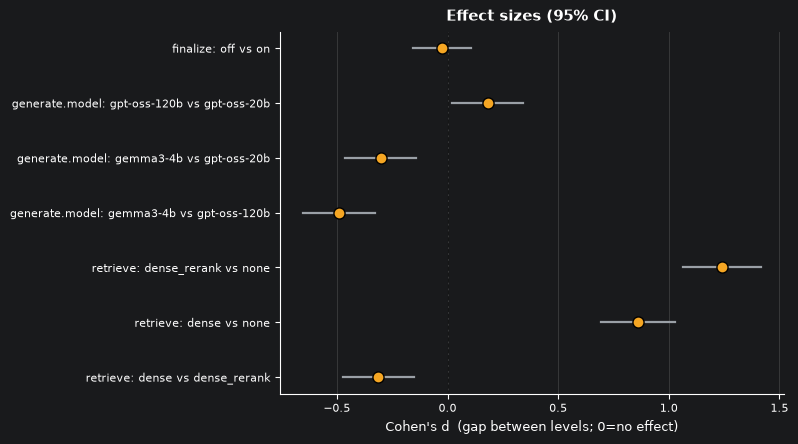

In [45]:
# Visual: the effect-size forest (per-level comparisons) + the marginal means per factor.
result.plot("effects")
print("marginal means per factor level:")
result.marginal_means

### E2 — Null calibration (false-positive rate)

E1 shows CAFE finds the effects we planted. E2 is the mirror image: does it **avoid finding effects
that aren't there?** We destroy every factor→quality link by **randomly shuffling the verdicts across
answers**, then refit. Under this null the true effect of *every* factor is zero — so a p-value is a
fair coin on [0, 1], and an honest test flags a factor "significant" (p < 0.05) only **~5%** of the
time. That 5% is the whole target.

We measure the **per-term** rate — across all `K × (number of factors)` individual factor-tests, what
fraction fired — because that's how CAFE reports results to you: **one p-value per factor**, and each of
those needs to be honest. (Reporting "did *any* of several factors fire?" is a different, always-higher
number — with `n` independent factors it's `1 − 0.95ⁿ`, e.g. ~14% for 3 — so we print it too, only to
show why the per-term rate is the right one to trust.) Cheap: re-analyses existing verdicts, no new LLM
calls; we calibrate the fast linear-model layer.

In [46]:
from cafe.judging.ratings import Rating, Ratings

def _permuted(ratings, rng):
    """Same verdicts, shuffled onto different answers → every factor's true effect is now zero."""
    scored = [(it.value, it.value_numeric) for it in ratings.items]
    rng.shuffle(scored)
    items = [Rating(obs_key=it.obs_key, config=dict(it.config), input_id=it.input_id,
                    rep=it.rep, judge_rep=it.judge_rep, value=v, value_numeric=vn)
             for it, (v, vn) in zip(ratings.items, scored)]
    return Ratings(rubric=ratings.rubric, judge_model=ratings.judge_model,
                   factors=list(ratings.factors), items=items)

K = 200 if SMOKE else 500
rng = random.Random(SEED)

n_fired = n_tests = any_runs = 0      # per-term counts + (for contrast) runs with ≥1 term firing
for _ in range(K):
    terms = cafe.fit_effects(_permuted(result.ratings, rng), interactions=1).terms
    fired = sum(bool(t["significant"]) for t in terms)   # how many factors this null run flagged
    n_fired += fired
    n_tests += len(terms)
    any_runs += (fired > 0)

per_factor = n_tests // K
print(f"permutations: {K}   ·   factors tested per run: {per_factor}   ·   total factor-tests: {n_tests}")
print(f"PER-TERM false-positive rate: {n_fired / n_tests:.1%}   ← the honest number (target ≈ 5%)")
print(f"  (contrast) 'any factor fired' rate: {any_runs / K:.1%}   "
      f"— structurally ~{1 - 0.95**per_factor:.0%} for {per_factor} factors, NOT 5%")

permutations: 500   ·   factors tested per run: 3   ·   total factor-tests: 1500
PER-TERM false-positive rate: 4.9%   ← the honest number (target ≈ 5%)
  (contrast) 'any factor fired' rate: 13.8%   — structurally ~14% for 3 factors, NOT 5%


### E4 — Holdout (within-distribution stability)

Is CAFE's "best config" a real winner, or did it just **overfit to these particular questions?** We
repeatedly split the questions in half at random and check whether the ranking of configs on one half
holds on the other (a fresh draw from the *same* distribution). This is a **within-distribution** claim
only — best on HotpotQA doesn't imply best on another task.

We do **not** just ask "is the exact top config the same on both halves" — because several configs at
the top are statistically **tied** (e.g. the top four here sit within ~0.04), so *which one* is #1 is a
coin-flip that flips even when the study is perfectly stable. Instead we measure stability three honest
ways over many random splits: **exact top-1 agreement** (expected to be modest — a tie means several
configs are jointly near-best), **top-3 overlap** (are the *good* configs consistently good?), and
**Spearman rank correlation** (is the whole ordering stable?). We report it on all 18 configs and,
separately, with the null `finalize` placebo **collapsed** (averaged out) — since a known no-op only
adds noise to the ranking, dropping it should sharpen stability without changing the story. High
top-3 overlap + high ρ = CAFE isn't overfitting.

In [47]:
from scipy.stats import spearmanr

rec = pd.DataFrame(result.records()).dropna(subset=["verdict"])
# Two config groupings: the full 18 (retrieve×model×placebo), and the placebo collapsed to 9.
rec["config_full"] = rec[["retrieve", "generate.model", "finalize"]].astype(str).agg(" · ".join, axis=1)
rec["config_core"] = rec[["retrieve", "generate.model"]].astype(str).agg(" · ".join, axis=1)
ids = list(dict.fromkeys(rec["input_id"]))          # unique question ids

def holdout_stability(config_col, n_splits=200, k=3):
    rng = random.Random(SEED)
    top1, topk, rhos = [], [], []
    for _ in range(n_splits):
        shuffled = ids[:]; rng.shuffle(shuffled)
        cut = len(shuffled) // 2
        A, B = set(shuffled[:cut]), set(shuffled[cut:])
        mA = rec[rec.input_id.isin(A)].groupby(config_col)["verdict"].mean()
        mB = rec[rec.input_id.isin(B)].groupby(config_col)["verdict"].mean()
        common = mA.index.intersection(mB.index)
        mA, mB = mA.reindex(common), mB.reindex(common)
        top1.append(mA.idxmax() == mB.idxmax())                                   # same #1?
        topk.append(len(set(mA.nlargest(k).index) & set(mB.nlargest(k).index)) / k)  # top-k overlap
        rhos.append(spearmanr(mA.values, mB.values).correlation)                  # ranking stable?
    return np.mean(top1), np.mean(topk), np.nanmean(rhos)

for label, col in [("all 18 configs (retrieve × model × placebo)", "config_full"),
                   ("9 configs, placebo collapsed (retrieve × model)", "config_core")]:
    t1, tk, rho = holdout_stability(col)
    print(f"{label}   (mean over 200 random 25/25 splits)")
    print(f"    exact top-1 agreement : {t1:.0%}   (modest is fine — the top configs are ~tied)")
    print(f"    top-3 overlap         : {tk:.0%}   (are the GOOD configs consistently good?)")
    print(f"    rank correlation ρ    : {rho:+.2f}  (is the whole ordering stable? +1 = identical)")
    print()

all 18 configs (retrieve × model × placebo)   (mean over 200 random 25/25 splits)
    exact top-1 agreement : 0%   (modest is fine — the top configs are ~tied)
    top-3 overlap         : 55%   (are the GOOD configs consistently good?)
    rank correlation ρ    : +0.91  (is the whole ordering stable? +1 = identical)

9 configs, placebo collapsed (retrieve × model)   (mean over 200 random 25/25 splits)
    exact top-1 agreement : 36%   (modest is fine — the top configs are ~tied)
    top-3 overlap         : 73%   (are the GOOD configs consistently good?)
    rank correlation ρ    : +0.93  (is the whole ordering stable? +1 = identical)



### E3 — Judge ↔ human agreement

Everything above rests on the **LLM judge's** verdicts, so the final check is whether the judge tracks
**human** judgment. We report two Krippendorff's α's on the ordinal 0/1/2 scale: **human ↔ human**
(the *ceiling* — do the humans even agree? the judge can't be expected to beat it) and **judge ↔ human**
(does the judge reach that ceiling?).

Two domain-aware raters independently scored a **stratified sample of 61 answers** spanning the judge's
verdict range (α is meaningless if every answer is a 2). They filled the sheet **blind** — no judge
score shown, no discussion (either would inflate agreement). Their labels are merged with the judge's
verdict and reasoning in `data/e3_combined_ratings.csv`, loaded below.

**Result.** Human ↔ human **α = 0.91** (a strong ceiling — the rubric is well-defined), and the judge
reaches it: judge ↔ human **α = 0.95 / 0.89** for the two raters, **0.92 overall** — all in the
"reliable" band (α ≥ 0.80). The judge agrees with independent experts about as well as they agree
with each other.

In [48]:
# STEP 1 — write the rating sheet (a stratified sample of answers spanning the judge's verdict range).
RATERS = ("you", "colleague")                       # ≥2 raters → a human↔human ceiling
N_RATE = 60                                          # answers to hand-rate (capped by what's available)
SHEET_PATH = os.path.join(DATA_DIR, f"human_sheet_{SAMPLE_KEY}.csv")

sheet = pd.DataFrame(cafe.answer_sheet(result, raters=RATERS))   # one row per (answer × rater)
verdict_by_ans = {r.obs_key: r.value_numeric for r in result.ratings.items}
uniq = sheet.drop_duplicates("answer_id").copy()
uniq["v"] = uniq["answer_id"].map(verdict_by_ans)

# Take an even slice from each judge-verdict bucket so the sample spans bad→good answers.
rng = random.Random(SEED)
per_bucket = max(1, N_RATE // max(1, uniq["v"].nunique()))
picked = []
for _v, grp in uniq.groupby("v", dropna=False):
    got = list(grp["answer_id"]); rng.shuffle(got)
    picked += got[:per_bucket]

sheet_sample = sheet[sheet["answer_id"].isin(set(picked))]
sheet_sample.to_csv(SHEET_PATH, index=False)
print(f"wrote {sheet_sample['answer_id'].nunique()} answers × {len(RATERS)} raters → {SHEET_PATH}")
print("→ open it, fill the `score` column (use the rubric's scale 0/1/2) independently per rater, save.")

wrote 61 answers × 2 raters → data/human_sheet_214644a9.csv
→ open it, fill the `score` column (use the rubric's scale 0/1/2) independently per rater, save.


In [ ]:
# STEP 2 — reliability from the completed rating sheet.
# The two raters filled their sheets independently and blind (no judge score shown); their labels were
# merged with the judge's verdict + reasoning into `e3_combined_ratings.csv`. We report Krippendorff's α
# on the ordinal 0/1/2 scale — this reproduces the paper's E3 numbers, standalone from the stored file.
import csv

RATINGS = os.path.join(DATA_DIR, "e3_combined_ratings.csv")

def _score(x):
    x = str(x).strip()
    return int(float(x)) if x not in ("", "nan") else None

rows  = list(csv.DictReader(open(RATINGS)))
judge = {r["answer_id"]: _score(r["judge"]) for r in rows if _score(r["judge"]) is not None}
human = cafe.human_ratings([
    {"answer_id": r["answer_id"], "rater": who, "score": _score(r[who])}
    for r in rows for who in ("you", "colleague") if _score(r[who]) is not None
])

# human ↔ human = the ceiling (do the raters agree?)
print(cafe.reliability(human=human, metric="ordinal").show())
print()
# judge + humans = does the judge reach the ceiling? (overall α + each pair)
print(cafe.reliability(raters={"judge": judge}, human=human, metric="ordinal").show())


inter-rater reliability — Krippendorff's α (ordinal)
  raters (2): you, colleague      answers rated by ≥2: 61

  overall α = 0.911   (reliable)

  α ≥ 0.80 reliable · 0.667–0.80 tentative · < 0.667 unreliable

inter-rater reliability — Krippendorff's α (ordinal)
  raters (3): judge, you, colleague      answers rated by ≥2: 61

  overall α = 0.916   (reliable)

  pairwise:
    judge ↔ you     α = +0.949   (n=60)
    judge ↔ colleague   α = +0.886   (n=60)
      you ↔ colleague   α = +0.911   (n=61)

  α ≥ 0.80 reliable · 0.667–0.80 tentative · < 0.667 unreliable
